# Origin of variance

There are various source of variance in the target acquisition (e.g., detector noise, photon noise etc.). 

Slicersim enables you to scan those to check their contribution.

To do so, you can *switch_off* any of them when generating a spectrum. The variance will reduce, and you can probe how much the variance has reduced with switching them off one at the time.

***
## Access list the variance sources

The core `slicersim.Simulation` object (up on which LazuliTarget are built) hold the list of implemented contributions

In [22]:
import slicersim

In [23]:
slicersim.Simulation.VARIANCE_SOURCES

['dark', 'thermal_dark', 'ron', 'target', 'host', 'background', 'thermal']

In [24]:
import numpy as np
import matplotlib.pyplot as plt

***
## switch_off read-out noise (ron)

To illustrate how variance estimation is done, let's generate a Supernovae spectrum while switching off the detector read-out noise contribution

In [27]:
# Load a Type Ia Supernovae lazuli object
lazuli_snia = slicersim.LazuliSN( redshift=1.2 )

In [28]:
# with read-out noise (normal case)
lbda, flux, variance = lazuli_snia.get_spectrum()

# with-out read-out noise
lbda, flux_noron, variance_noron = lazuli_snia.get_spectrum(switch_off="ron")

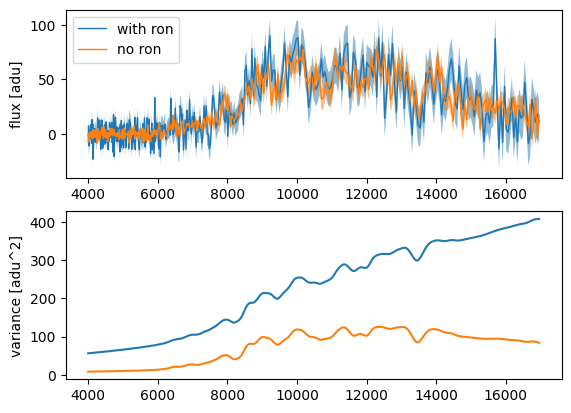

In [29]:

fig, (ax, ax_var) = plt.subplots(nrows=2)

# with read-out noise
ax.plot(lbda, flux, lw=1, label="with ron")
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.5)

# with-out read-out noise
ax.plot(lbda, flux_noron, lw=1, label="no ron")
ax.fill_between(lbda, 
                flux_noron+np.sqrt(variance_noron), 
                flux_noron-np.sqrt(variance_noron), alpha=0.5)
ax.set_ylabel("flux [adu]")

# Variance ratio
ax_var.plot(lbda, variance, label="with ron")
ax_var.plot(lbda, variance_noron, label="no ron")
ax_var.set_ylabel("variance [adu^2]")

ax.legend()

In that example, the readout noise seems to be the dominating source of variance in the red-part of the spectra

***
## Access the detailed variance contribution

You can do this exercise of switching off each contribution one at the time and store and compare the resulting variance. 

For convinience, this is what `get_variance_contribution()` does for you

In [30]:
%%time
variance_source_df = lazuli_snia.get_variance_contribution()

CPU times: user 1.05 s, sys: 370 ms, total: 1.42 s
Wall time: 1.44 s


In [31]:
variance_source_df

,lbda,flux,variance,dark,thermal_dark,ron,target,host,background,thermal
0,3999.990000,0.003376,56.383037,6.206999,2.216785,47.929776,0.004511,0.0,0.024968,0.000000
1,4005.418559,0.006850,56.456030,6.211882,2.218529,47.967487,0.009155,0.0,0.048978,0.000000
2,4010.868075,0.009783,56.521061,6.216790,2.220282,48.005387,0.013075,0.0,0.065528,0.000000
3,4016.338827,0.011337,56.571699,6.221723,2.222044,48.043478,0.015152,0.0,0.069304,0.000000
4,4021.831091,0.012406,56.618498,6.226681,2.223815,48.081763,0.016581,0.0,0.069660,0.000000
...,...,...,...,...,...,...,...,...,...,...
451,16753.105182,13.407362,403.596087,40.920476,14.614100,316.358359,20.130668,0.0,9.797745,2.285449
452,16804.786950,13.512731,405.380971,41.154525,14.697684,318.172582,20.276890,0.0,9.236264,2.362107
453,16856.367356,13.285528,406.582479,41.388128,14.781125,319.967019,19.912004,0.0,8.622079,2.416640
454,16907.847061,12.804887,407.257879,41.621384,14.864458,321.744195,19.081045,0.0,7.980714,2.435835


use `simulation.show_variance_sources(variance_source_df)` for a quick view

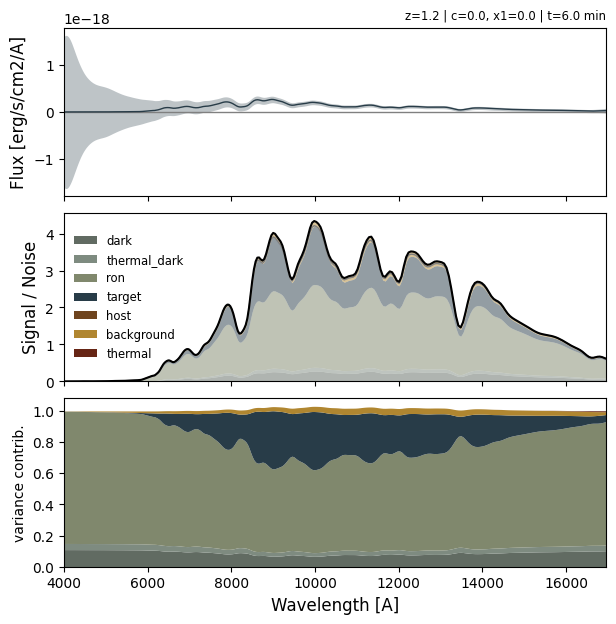

In [32]:
fig = lazuli_snia.simulation.show_variance_sources(variance_source_df)

So indeed, the read-out noise dominates at all wavelengths, we some target photon-noise near 1 micrometer